In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_FIG_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
FIG_DIR_ROOT = V3LE_FIG_ROOT / "mean_bias"

In [1]:
from __future__ import annotations

import os
import glob
import re
import json
import time
import datetime
from typing import Dict, Tuple, Optional
from global_land_mask import globe

import xarray as xr

import unicodedata
import pprint 
import shutil

from typing import Optional

try:
    # xCDAT for CF bounds utilities and lon handling
    from xcdat import open_dataset as xcdat_open
    _HAVE_XCDAT = True
except Exception:
    xcdat_open = xr.open_dataset
    _HAVE_XCDAT = False

try:
    import xskillscore as xs
    _HAVE_XS = True
except Exception:
    _HAVE_XS = False

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from collections.abc import Mapping

from matplotlib.cm import ScalarMappable
from matplotlib.offsetbox import AnchoredText

# Local imports
from exp_info import RUN_CATALOG, REGION_CATALOG, VARIABLE_CATALOG


In [2]:
class ExpDataReader:
    def __init__(
        self,
        data_dir: str,
        regnam: str,
        dtype: str,
        *,
        run_catalog: Optional[Dict[str, Dict[str, str]]] = None,
        region_catalog: Optional[Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]]] = None,
        sfc_mask_ref: str = "MODIS.observation",
        sfc_mask_var: str = "TS",
        sfc_mask_kind: str = "land",
        debug_key: Optional[str] = None,
        verbose: bool = False,
    ):
        self.data_dir = os.path.abspath(data_dir)
        self.regnam = regnam
        self.dtype = dtype
        self.sfc_mask_ref = sfc_mask_ref
        
        # copy to avoid accidental mutation of module-level defaults
        self.run_catalog = dict(RUN_CATALOG) if run_catalog is None else dict(run_catalog)
        self.region_catalog = dict(REGION_CATALOG) if region_catalog is None else dict(region_catalog)

        if self.sfc_mask_ref not in self.run_catalog:
            raise KeyError(f"sfc_mask_ref='{self.sfc_mask_ref}' not found in run_catalog")

        self.sfc_mask_var = sfc_mask_var
        self.sfc_mask_kind = sfc_mask_kind
        self.debug_key = debug_key
        self.verbose = verbose

        # region bounds (store both slices and raw bounds)
        (lat_min, lat_max), (lon_min, lon_max) = self._region_bounds(self.regnam)
        lon_min, lon_max = self._normalize_region_lon_bounds(lon_min, lon_max)
        self.lat_slice = slice(lat_min, lat_max)
        self.lon_slice = slice(lon_min, lon_max)
        self.lat_bounds = (lat_min, lat_max)
        self.lon_bounds = (lon_min, lon_max)

        self.exp_dict: Dict[str, xr.Dataset] = {}
        self.sfc_mask: Optional[xr.DataArray] = None

    def _meta_field(self, meta, field: str):
        """Return run metadata field from object or dict."""
        if hasattr(meta, field):
            return getattr(meta, field)
        if isinstance(meta, dict) and field in meta:
            return meta[field]
        raise KeyError(f"Run meta missing '{field}': {field} not found in {meta!r}")

    def gen_region_mask(self, data_dir, exp, dtype, period, var, regnam, debug=False):
        """
        Build a region-aware mask aligned to the reference grid.
        - base mask: finite data in `var` (1 where finite, 0 where NaN)
        - optional land/ocean filter via global_land_mask (if self.sfc_mask_kind in {'land','ocean'})
        - cropped to the region `regnam`
        Returns: xr.DataArray int8 with dims ('lat','lon') named 'region_mask'
        """
        # --- open & normalize lon ---
        refpath = os.path.join(data_dir, f"{exp}.{dtype}.{period}.nc")
        refds = xcdat_open(refpath, decode_times=True)

        lon_name = "lon" if "lon" in refds.coords else ("longitude" if "longitude" in refds.coords else None)
        if lon_name is None:
            raise ValueError("No longitude coordinate found ('lon' or 'longitude').")

        lons = refds[lon_name]
        # wrap 0–360 → −180..180 and sort
        if float(lons.min()) > -1.0 or float(lons.max()) > 180.0:
            new_lons = ((lons + 180) % 360) - 180
            refds = refds.assign_coords({lon_name: new_lons})
        refds = refds.sortby(lon_name)
        if lon_name == "longitude":
            refds = refds.rename({"longitude": "lon"})

        # ensure bounds (optional)
        refds = refds.bounds.add_missing_bounds()

        rlats = refds["lat"].values
        rlons = refds["lon"].values

        # --- get a 2D slice of var for base valid-data mask ---
        src = refds[var]
        drop_dims = [d for d in src.dims if d not in ("lat", "lon")]
        src2d = src.isel({d: 0 for d in drop_dims}).squeeze() if drop_dims else src.squeeze()

        # base mask: 1 where data finite, else 0
        base = xr.where(xr.apply_ufunc(np.isfinite, src2d), 1, 0).astype(np.int8).rename("region_mask")

        if debug:
            tot = int(base.size); val = int((base > 0).sum())
            print(f"[mask-base] finite cells={val}/{tot} ({val/tot:.1%})")

        # --- optional land/ocean filter ---
        kind = getattr(self, "sfc_mask_kind", None)
        if kind in {"land", "ocean"}:
            try:
                from global_land_mask import globe
            except Exception as e:
                raise ImportError("Please `pip install global-land-mask` to use land/ocean masking.") from e

            lon_grid, lat_grid = np.meshgrid(rlons, rlats)
            reg_bool = globe.is_land(lat_grid, lon_grid) if kind == "land" else globe.is_ocean(lat_grid, lon_grid)
            reg_mask = xr.DataArray(reg_bool, coords={"lat": rlats, "lon": rlons}, dims=("lat", "lon"))
            base = xr.where(reg_mask, base, 0).astype(np.int8)

            if debug:
                val2 = int((base > 0).sum()); tot2 = int(base.size)
                print(f"[mask-{kind}] kept cells={val2}/{tot2} ({val2/tot2:.1%})")

        # --- ensure latitude ascending for consistent slicing ---
        if np.diff(base["lat"].values).mean() < 0:
            base = base.sortby("lat")

        # --- crop to region ---
        (lat_min, lat_max), (lon_min, lon_max) = self._region_bounds(regnam)
        lon_min, lon_max = self._normalize_region_lon_bounds(lon_min, lon_max)

        out = base.sel(lat=slice(lat_min, lat_max))

        if lon_min <= lon_max:
            out = out.sel(lon=slice(lon_min, lon_max))
        else:
            left  = out.sel(lon=slice(lon_min, 180))
            right = out.sel(lon=slice(-180, lon_max))
            out = xr.concat([left, right], dim="lon").sortby("lon")

        out = out.astype(np.int8).rename("region_mask")
        out.attrs.update({
            "region": regnam,
            "lon_bounds": (lon_min, lon_max),
            "lat_bounds": (lat_min, lat_max),
            "kind": getattr(self, "sfc_mask_kind", "any"),
        })

        if debug:
            totR = int(out.size); valR = int((out > 0).sum())
            print(f"[crop-{regnam}] kept cells={valR}/{totR} ({valR/totR:.1%}); "
                  f"extent=[{lon_min:.1f},{lon_max:.1f}]×[{lat_min:.1f},{lat_max:.1f}]")

        return out

    def _region_bounds(self, regnam: str):
        """Return ((lat_min, lat_max), (lon_min, lon_max)) from Region object/dict/tuple."""
        try:
            region = self.region_catalog[regnam]
        except KeyError:
            raise ValueError(f"Region '{regnam}' not found. Available: {list(self.region_catalog)}")

        # Region dataclass / object
        if hasattr(region, "lat_range") and hasattr(region, "lon_range"):
            (lat_min, lat_max) = region.lat_range
            (lon_min, lon_max) = region.lon_range
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))

        # Dict style
        if isinstance(region, dict) and "lat_range" in region and "lon_range" in region:
            (lat_min, lat_max) = region["lat_range"]
            (lon_min, lon_max) = region["lon_range"]
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))

        # Tuple/list style
        try:
            (lat_min, lat_max), (lon_min, lon_max) = region
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))
        except Exception:
            raise TypeError(
                "REGION_CATALOG entry must be a Region with lat_range/lon_range, "
                "a dict with those keys, or ((lat_min,lat_max),(lon_min,lon_max))."
            )
        
    # --- longitude handling ---
    @staticmethod
    def _is_0_360(lons) -> bool:
        """
        Detect if longitude grid is in [0, 360).
        Works even for shifted grids like 0.5–359.5.
        """
        a = np.asarray(lons)
        minlon, maxlon = np.nanmin(a), np.nanmax(a)
        if minlon >= 0.0 and maxlon <= 360.0:
            return True
        if (0.0 <= minlon < 1.0) and (359.0 < maxlon <= 360.0):
            return True
        return False

    @staticmethod
    def _wrap_to_180(lon_vals):
        lon_vals = (lon_vals + 180.0) % 360.0 - 180.0
        return lon_vals

    def _normalize_longitude(self, ds: xr.Dataset) -> xr.Dataset:
        """Ensure ds.lon is in [-180, 180] and sorted ascending."""
        lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
        if lon_name is None:
            return ds  # nothing to do

        lons = ds[lon_name].values
        if self._is_0_360(lons):
            lons = self._wrap_to_180(lons)
            ds = ds.assign_coords({lon_name: lons})
        # always sort by lon
        ds = ds.sortby(lon_name)

        # For consistency rename to 'lon' if it's 'longitude'
        if lon_name == "longitude":
            ds = ds.rename({lon_name: "lon"})
        return ds

    @staticmethod
    def _normalize_region_lon_bounds(lon_min: float, lon_max: float):
        """Ensure region bounds use the [-180, 180] convention."""
        if -180.0 <= lon_min <= 180.0 and -180.0 <= lon_max <= 180.0:
            return lon_min, lon_max
        lon_min = (lon_min + 180.0) % 360.0 - 180.0
        lon_max = (lon_max + 180.0) % 360.0 - 180.0
        return lon_min, lon_max

    def _select_region_and_bounds(self, ds: xr.Dataset) -> xr.Dataset:
        """Subset by lat and lon, handling descending lat and dateline crossing."""
        ds = self._maybe_add_bounds(ds)

        # latitude
        if "lat" in ds.coords:
            lat_min, lat_max = self.lat_bounds
            lat_vals = ds["lat"].values
            lat_asc = bool(np.diff(lat_vals).mean() > 0)
            lat_slice = slice(lat_min, lat_max) if lat_asc else slice(lat_max, lat_min)
            ds = ds.sel(lat=lat_slice)

        # longitude
        if "lon" not in ds.coords:
            return ds

        lon_min, lon_max = self.lon_bounds
        if lon_min <= lon_max:
            return ds.sel(lon=slice(lon_min, lon_max))
        else:
            # crosses dateline
            left  = ds.sel(lon=slice(lon_min, 180))
            right = ds.sel(lon=slice(-180, lon_max))
            right = right.assign_coords(lon=self._wrap_to_180(right["lon"]))
            return xr.concat([left, right], dim="lon").sortby("lon")

    def _maybe_add_bounds(self, ds: xr.Dataset) -> xr.Dataset:
        if _HAVE_XCDAT:
            try:
                ds = ds.bounds.add_missing_bounds()
            except Exception:
                pass
        return ds

    def _sync_time_to_reference(self):
        ref_time = self.exp_dict[self.sfc_mask_ref]["time"]
        for k in list(self.exp_dict.keys()):
            if k != self.sfc_mask_ref and "time" in self.exp_dict[k].coords:
                self.exp_dict[k] = self.exp_dict[k].assign_coords(time=ref_time)

    def _debug_print(self, key, path, lats0=None, lons0=None):
        if key != self.debug_key:
            return
        print(f"[DEBUG] {key}")
        if lats0 is not None:
            print("  lats0:", np.asarray(lats0).min(), "→", np.asarray(lats0).max())
        if lons0 is not None:
            print("  lons0:", np.asarray(lons0).min(), "→", np.asarray(lons0).max())
        print("  period:", self.run_catalog[key]["period"])
        print("  path:", path)
        print("  lon(post):", self.exp_dict[key]["lon"].min().item(), "→", self.exp_dict[key]["lon"].max().item())

    def _normalize_period_str(self, s: str) -> str:
        _DASHES = {
            "\u2010": "-",  # hyphen
            "\u2011": "-",  # non-breaking hyphen
            "\u2012": "-",  # figure dash
            "\u2013": "-",  # en dash
            "\u2014": "-",  # em dash
            "\u2212": "-",  # minus sign
        }
        s = unicodedata.normalize("NFKC", s)
        return s.translate(str.maketrans(_DASHES)).strip()
    
    # --- main API ---
    def read(self, debug=False):
        for exp_key, meta in self.run_catalog.items():
            raw_period = self._meta_field(meta, "period")
            period = self._normalize_period_str(raw_period)
            nc_path = os.path.join(self.data_dir, f"{exp_key}.{self.dtype}.{period}.nc")
            if self.verbose:
                print(f"Loading: {nc_path}")
            if not os.path.exists(nc_path):
                raise FileNotFoundError(f"File not found for run '{exp_key}': {nc_path}")

            ds = xcdat_open(nc_path, decode_times=True)

            # pick a reasonable debug variable
            dbg_var = "TS" if "TS" in ds.data_vars else ("FLNS" if "FLNS" in ds.data_vars else None)
            if debug and dbg_var:
                da0 = ds[dbg_var]
                tot0   = int(da0.size)
                valid0 = int(da0.notnull().sum())
                lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
                if lon_name:
                    print(f"[open] {exp_key}: valid={valid0}/{tot0} ({valid0/tot0:.1%}); "
                          f"lon-range={float(ds[lon_name].min()):.2f}..{float(ds[lon_name].max()):.2f}")
                else:
                    print(f"[open] {exp_key}: valid={valid0}/{tot0} ({valid0/tot0:.1%}); no lon")

            # lon normalize
            ds = self._normalize_longitude(ds)
            if debug and dbg_var:
                daN = ds[dbg_var]
                totN   = int(daN.size)
                validN = int(daN.notnull().sum())
                print(f"[norm] {exp_key}: valid={validN}/{totN} ({validN/totN:.1%}); "
                      f"lon-range={float(ds['lon'].min()):.2f}..{float(ds['lon'].max()):.2f}")

            # region crop (handles descending lat and dateline)
            ds = self._select_region_and_bounds(ds)
            if debug and dbg_var:
                daR = ds[dbg_var]
                totR   = int(daR.size)
                validR = int(daR.notnull().sum())
                print(f"[crop] {exp_key}: valid={validR}/{totR} ({validR/totR:.1%}); "
                      f"extent={self.lon_bounds}×{self.lat_bounds}")

            self.exp_dict[exp_key] = ds
            if debug:
                lats0 = ds["lat"].values if "lat" in ds.coords else None
                lons0 = ds["lon"].values if "lon" in ds.coords else None
                self._debug_print(exp_key, nc_path, lats0, lons0)

        if self.sfc_mask_ref not in self.exp_dict:
            raise KeyError(f"Reference '{self.sfc_mask_ref}' not loaded (after reading).")

        # Align time to reference
        self._sync_time_to_reference()

        # Build land mask using the reference run's period
        ref_meta = self.run_catalog[self.sfc_mask_ref]
        ref_period_raw = self._meta_field(ref_meta, "period")
        ref_period = self._normalize_period_str(ref_period_raw)

        # generate region/land mask consistent with reference
        self.sfc_mask = self.gen_region_mask(
            self.data_dir, self.sfc_mask_ref, self.dtype, ref_period,
            self.sfc_mask_var, self.regnam, debug=debug
        )
        return self.run_catalog, self.exp_dict, self.sfc_mask

In [3]:
class ZonalMeanBiasPlotter:
    """
    Plot zonal-mean (lon-avg) bias as Hovmöller (lat × month) across models.
    Self-contained and includes the merged derive_zonal_metrics_data logic.
    """

    def __init__(self, run_dict, df, lmsk, var_dict, months, regnam, model_list,
                 plot_type, fgw=35, fgh=12, ws=0.5, hs=0.5, region_catalog=None,
                 rms_is_sqrt=True, debug=True):
        self.run_dict   = run_dict
        self.df         = df
        self.lmsk       = lmsk
        self.var_dict   = var_dict
        self.var        = var_dict['var']
        self.months     = list(months)
        self.regnam     = regnam
        self.model_list = list(model_list)
        self.plot_type  = plot_type
        self.fgw        = float(fgw); self.fgh = float(fgh)
        self.ws         = float(ws);  self.hs  = float(hs)
        self.region_catalog = region_catalog or {}
        self.lat_range, self.lon_range = self._region_bounds(regnam)
        self.cmap, self.clevs = self._build_colormap_levels(self.var_dict)
        self.refmodel = self.var_dict.get('ref', None)
        self.ncols = len(self.model_list)
        self.rms_is_sqrt = bool(rms_is_sqrt)
        self.debug = bool(debug)

    # ---------- visuals ----------
    @staticmethod
    def _build_colormap_levels(var_dict):
        color_list4 = ['darkblue', 'lightblue', 'white', 'lightyellow', 'orange', 'firebrick']
        nodes = [0.0, 0.3, 0.5, 0.5, 0.8, 1.0]
        cmap = matcolors.LinearSegmentedColormap.from_list('mybluewhitered', list(zip(nodes, color_list4)))
        clevs = np.linspace(var_dict['min'], var_dict['max'], var_dict['nlev'])
        return cmap, clevs

    # ---------- region ----------
    def _region_bounds(self, regnam):
        lat_rng = (-90.0, 90.0); lon_rng = (-180.0, 180.0)
        region = self.region_catalog.get(regnam, None)
        if region is not None:
            if isinstance(region, dict) and "lat_range" in region and "lon_range" in region:
                lat_rng = tuple(region["lat_range"]); lon_rng = tuple(region["lon_range"])
            else:
                try:
                    lat_rng, lon_rng = region
                except Exception:
                    pass
        if regnam == 'Antarctic':
            lat_rng = (-90.0, min(lat_rng[1], -50.0))
        elif regnam == 'PolarN':
            lat_rng = (max(lat_rng[0], 50.0), 90.0)
        return lat_rng, lon_rng

    @staticmethod
    def _coslat_weights(lat):
        return xr.DataArray(np.cos(np.deg2rad(lat)), dims=['lat'], coords={'lat': lat})

    @staticmethod
    def _meta_get(meta, key, default=None):
        from collections.abc import Mapping
        if isinstance(meta, Mapping): return meta.get(key, default)
        return getattr(meta, key, default)

    def _xyticks_for_region(self):
        if self.regnam == 'Antarctic':
            return ([-90, -80, -70, -60, -50], ['90°S','80°S','70°S','60°S','50°S'])
        elif self.regnam in ('PolarN','Greenland'):
            return ([50,60,70,80,90], ['50°N','60°N','70°N','80°N','90°N'])
        elif self.regnam == 'Atlantic':
            return ([10,30,50,70,90], ['10°N','30°N','50°N','70°N','90°N'])
        elif self.regnam == 'CONUS':
            return ([-5,10,25,40,55], ['5°S','10°N','25°N','40°N','55°N'])
        else:
            return ([-90,-45,0,45,90], ['90°S','45°S','0°','45°N','90°N'])

    def _month_labels_shifted(self):
        idx_shift = 4 if self.regnam in ['Antarctic'] else 1
        months = list(self.months)
        if len(months) == 12:
            return months[-idx_shift:] + months[:-idx_shift], idx_shift
        return months, 0

    # ---------- data helpers ----------
    def _to_mask_like(self, lmsk, like_da: xr.DataArray) -> xr.DataArray:
        # Accept DataArray, Dataset with a 'mask' var, or ndarray-like
        if isinstance(lmsk, xr.Dataset):
            # try common names
            for key in ('mask', 'landmask', 'sftlf'):
                if key in lmsk:
                    lmsk = lmsk[key]
                    break
            else:
                raise ValueError("Mask Dataset provided but no ['mask','landmask','sftlf'] var found.")
        if isinstance(lmsk, xr.DataArray):
            m = lmsk
            if 'lat' in like_da.coords and 'lat' in m.coords:
                m = m.sel(lat=like_da.lat, method='nearest')
            if 'lon' in like_da.coords and 'lon' in m.coords:
                m = m.sel(lon=like_da.lon, method='nearest')
            m = m.astype('float64')
        else:
            m = xr.DataArray(np.asarray(lmsk), dims=['lat','lon'],
                             coords={'lat': like_da.lat, 'lon': like_da.lon}).astype('float64')
        # Normalize to {0,1}
        m = xr.where(m > 0.5, 1.0, 0.0)
        return m

    def _restrict_lonlat(self, da: xr.DataArray) -> xr.DataArray:
        if 'lon' in da.coords:
            lon = da['lon']
            if float(lon.max()) > 180.0:
                new_lon = ((lon + 180.0) % 360.0) - 180.0
                da = da.assign_coords(lon=new_lon).sortby('lon')
        lat0, lat1 = self.lat_range; lon0, lon1 = self.lon_range
        if 'lat' in da.coords:
            da = da.sel(lat=slice(lat0, lat1))
        if 'lon' in da.coords:
            if lon0 <= lon1:
                da = da.sel(lon=slice(lon0, lon1))
            else:
                da = xr.concat([da.sel(lon=slice(lon0, 180)),
                                da.sel(lon=slice(-180, lon1))], dim='lon')
        return da

    def _monthly_dayweighted(self, da: xr.DataArray) -> xr.DataArray:
        """Return monthly means with day weighting if 'time' exists; otherwise
        pass through if already on 'month'."""
        if 'time' in da.dims:
            da = da.astype('float64')
            w = da['time'].dt.days_in_month.astype('float64')
            num = (da * w).groupby('time.month').sum('time')
            den = w.groupby('time.month').sum('time')
            out = num / den  # [month, ...]
            # ensure month is 1..12 int
            out = out.sortby('month')
            return out
        elif 'month' in da.dims:
            # Assume already monthly means; ensure integer month coord if possible
            if not np.issubdtype(da['month'].dtype, np.integer):
                try:
                    da = da.assign_coords(month=da['month'].astype(int))
                except Exception:
                    pass
            return da
        else:
            raise ValueError("Expected 'time' or 'month' dimension for monthly aggregation.")


    def _zonal_mean_lat_x_month(self, ds: xr.Dataset, var: str) -> xr.DataArray:
        da = self._restrict_lonlat(ds[var])
        m = self._to_mask_like(self.lmsk, da)
        da = da.where(m > 0)
        mmean = self._monthly_dayweighted(da)   # [month, lat, lon] or [month, lat] if lon absent
        if 'lon' in mmean.dims:
            return mmean.mean('lon', skipna=True)  # [month, lat]
        return mmean
    
    # ---------- merged metrics logic ----------
    def _derive_zonal_metrics_data(self, var, dso, dsm):
        mod_avg = self._zonal_mean_lat_x_month(dsm, var)  # [month, lat]
        mec = {}

        if self.debug:
            try:
                print(f"mod_min_max_{float(dsm[var].min()):.4g}_{float(dsm[var].max()):.4g}")
            except Exception:
                pass
        
        # cos(lat) weights broadcast to [month, lat]
        wlat = self._coslat_weights(mod_avg['lat'])
        w2d = xr.ones_like(mod_avg) * wlat

        mec['mean'] = (np.abs(mod_avg).weighted(w2d)).mean(('month','lat'))
        msq = (mod_avg**2).weighted(w2d).mean(('month','lat'))
        mec['rmsm'] = np.sqrt(msq) if self.rms_is_sqrt else msq
        dat_out = mod_avg.copy()
        
        if isinstance(dso, xr.Dataset) and (var in dso):
            if self.debug:
                try:
                    print(f"obs_min_max_{float(dso[var].min()):.4g}_{float(dso[var].max()):.4g}")
                except Exception:
                    pass

            obs_avg = self._zonal_mean_lat_x_month(dso, var)    # [month, lat]
            mod_avg, obs_avg = xr.align(mod_avg, obs_avg, join='inner')

            w2d = xr.ones_like(mod_avg) * self._coslat_weights(mod_avg['lat'])
            osq = (obs_avg**2).weighted(w2d).mean(('month','lat'))
            mec['rmso'] = np.sqrt(osq) if self.rms_is_sqrt else osq

            mec['rmse'] = xs.rmse(obs_avg, mod_avg, dim=['month','lat'],
                                   weights=w2d.astype('float64'), skipna=True)
            mec['pcor'] = xs.pearson_r(obs_avg, mod_avg, dim=['month','lat'],
                                       weights=w2d.astype('float64'), skipna=True)
            dat_out = mod_avg - obs_avg

        return dat_out, mec
    
    # format labels
    def format_lat(self,val):
        hemi = "N" if val >= 0 else "S"
        return f"{abs(int(round(val)))}°{hemi}"

    # ---------- plot ----------
    def plot(self, show=False, return_fig=False):
        fig, axes = plt.subplots(nrows=1, ncols=self.ncols, figsize=(self.fgw, self.fgh))

        frac = 12.0 / 35.0
        fontz = 14 * self.fgw / self.fgh * frac

        cax = np.empty((self.ncols,), dtype=object)
        contour = np.empty((self.ncols,), dtype=object)
        conline = np.empty((self.ncols,), dtype=object)

        xticks, xticklabels = self._xyticks_for_region()
        month_labels, roll_n = self._month_labels_shifted()

        vname = self.var; vunt = self.var_dict['unit']; vfac = self.var_dict['fac']  
        cbar_title = f"{vname} ({vunt})"
        clevs = self.clevs
        cmap  = self.cmap
        norm  = matcolors.BoundaryNorm(clevs, cmap.N)

        for i, model in enumerate(self.model_list):
            if self.plot_type == "model_vs_obs" and self.refmodel:
                vplt, mec = self._derive_zonal_metrics_data(self.var, self.df.get(self.refmodel), self.df[model])
                metrics_str = f"RMSE: {float(mec['rmse'].values):.1f}\nPCOR: {float(mec['pcor'].values):.2f}"
            else:
                vplt, mec = self._derive_zonal_metrics_data(self.var, None, self.df[model])
                metrics_str = f"Mean: {float(mec['mean'].values):.1f}"

            vplt_disp = vplt.roll(month=roll_n) * vfac
            yvals = np.arange(1, vplt_disp.sizes['month'] + 1)
            
            #print(vplt_disp['lat'].values)
            #print(xxxxb)
            
            axes.flat[i].set_aspect(3.5, adjustable='box')
            contour[i] = axes.flat[i].contourf(
                vplt_disp['lat'].values, yvals, vplt_disp.values,
                levels=clevs, cmap=cmap, extend='both', zorder=0
            )
            conline[i] = axes.flat[i].contour(
                vplt_disp['lat'].values, yvals, vplt_disp.values,
                clevs, colors='k', linewidths=0.8
            )
            axes.flat[i].clabel(conline[i], inline=True, fontsize=max(fontz*0.95, 8), colors='cyan')

            cax[i] = inset_axes(
                axes.flat[i], width='5%', height='100%', loc='lower right',
                bbox_to_anchor=(0.1, 0, 1, 1), bbox_transform=axes.flat[i].transAxes, borderpad=0
            )
            cbar = plt.colorbar(contour[i], cax=cax[i], cmap=cmap, extend='both')
            cbar.set_label(cbar_title, rotation=270, labelpad=15, fontsize=fontz*1.1)
            cbar.ax.tick_params(labelsize=max(fontz*0.9, 8))
            cbar.outline.set_edgecolor('black'); cbar.outline.set_linewidth(0.2)

            # --- axis/tick setup ---
            lat_vals = vplt_disp['lat'].values
            # Round outward to ensure full coverage
            latmin = np.floor(lat_vals.min())   # round down
            latmax = np.ceil(lat_vals.max())    # round up
            axes.flat[i].set_xlim(latmin, latmax)

            locator = mticker.MaxNLocator(nbins=5, steps=[1,2,5,10])
            xticks_locs = locator.tick_values(latmin, latmax)
            xticks_desired = [v for v in xticks_locs if v >= latmin and v <= latmax]

            axes.flat[i].set_xticks(xticks_desired)
            axes.flat[i].set_xticklabels([self.format_lat(v) for v in xticks_desired],
                                         fontsize=max(fontz, 9))

            # Only show xticklabels on bottom row
            if axes.ndim == 1:
                row, col = 0, i
            else:
                row, col = divmod(i, self.ncols)

            if row == (axes.shape[0]-1 if axes.ndim > 1 else 0):
                axes.flat[i].set_xticklabels([self.format_lat(v) for v in xticks_desired],
                                             fontsize=max(fontz, 9))
            else:
                axes.flat[i].set_xticklabels([])

    
            #xtick1 = [x for x in xticks if (x >= xdata.min()-1e-9 and x <= xdata.max()+1e-9)]
            #axes.flat[i].set_xticks(xtick1)
            
            ## Only show xticklabels on the bottom row
            #if i >= self.ncols:   # for multiple rows case
            #    row, col = divmod(i, self.ncols)
            #else:
            #    row, col = 0, i   # single row case

            #if row == (0 if axes.ndim==1 else axes.shape[0]-1):
            #    axes.flat[i].set_xticklabels(
            #        [lbl for x,lbl in zip(xtick1, xticklabels) if x in xtick1],
            #        fontsize=max(fontz, 9)
            #    )
            #else:
            #    axes.flat[i].set_xticklabels([])
            
            axes.flat[i].set_yticks(yvals);  axes.flat[i].set_yticklabels(month_labels, fontsize=max(fontz, 9))

            model_meta = self.run_dict[model]
            model_name = self._meta_get(model_meta, 'name', str(model))
            axes.flat[i].set_title(model_name, loc='left', fontsize=fontz*1.2, pad=10)
            axes.flat[i].set_title(metrics_str, loc='right', color='red', fontsize=fontz*1.0, pad=10)

        plt.subplots_adjust(hspace=self.hs, wspace=self.ws)

        last_model = self.model_list[-1]
        last_meta = self.run_dict[last_model]
        period = self._meta_get(last_meta, 'period', 'NA')
        ref_str = self.refmodel if (self.plot_type == "model_vs_obs" and self.refmodel) else 'NA'
        outname = f"fig_zonalmean_{self.plot_type}_{ref_str}_{self.var}_{self.regnam}_{period}.pdf"

        if return_fig:
            return fig, axes

        plt.ioff()
        fig.savefig(outname, bbox_inches='tight')
        if show:
            plt.show()
        plt.close(fig)
        return outname


reference data and period: HadISST, 2001–2018
processed region: Atlantic, lat=(10,75), lon=(-75,0)
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/HadISST.analysis.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/MODIS.observation.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/CERES_EBAF.observation.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/MERRA2.analysis.climo.2001-2018.nc


2025-09-14 21:02:13,740 [WARNING]: dataset.py(decode_time:360) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.
2025-09-14 21:02:13,740 [WARNING]: dataset.py(decode_time:360) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.


Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/ERA5.analysis.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/ERA5.ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.amip_ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.historical_ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.piControl.climo.0101-0200.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.piControl.hexagonal.climo.0001-0050.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/20250327.v3.SORRME3r3.piControl.alfred2.chrysalis.climo.0041-0050.nc
Loaded runs:
['HadISST.analysis',
 'MODIS.obs

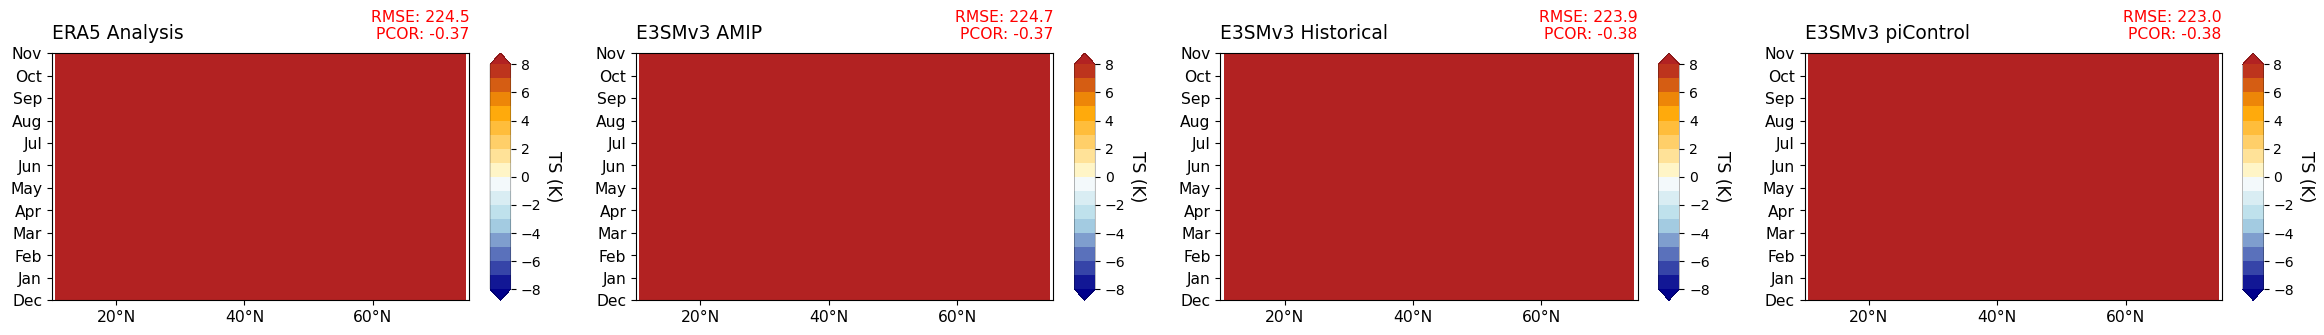

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_TS_Atlantic_model_vs_obs_2001-2018.pdf
[skip] TURFLX: missing in ['MERRA2.analysis', 'ERA5.analysis', 'v3.LR.amip_ensmn', 'v3.LR.historical_ensmn', 'v3.LR.piControl']
mod_min_max_-22.66_398.9
obs_min_max_-16.7_323.7
mod_min_max_-15.69_373.6
obs_min_max_-16.7_323.7
mod_min_max_-16.55_437.8
obs_min_max_-16.7_323.7
mod_min_max_-13.09_435.4
obs_min_max_-16.7_323.7


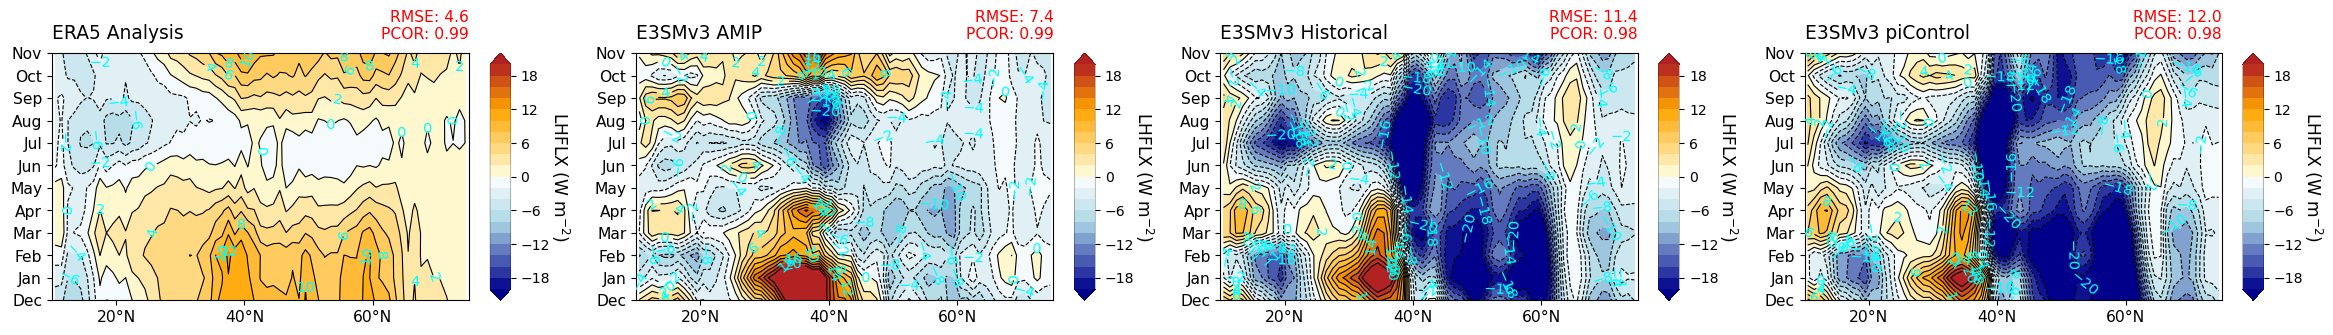

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_LHFLX_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-47.58_202.7
obs_min_max_-47.61_170.5
mod_min_max_-41.07_157.9
obs_min_max_-47.61_170.5
mod_min_max_-42.39_202
obs_min_max_-47.61_170.5
mod_min_max_-43.68_213.2
obs_min_max_-47.61_170.5


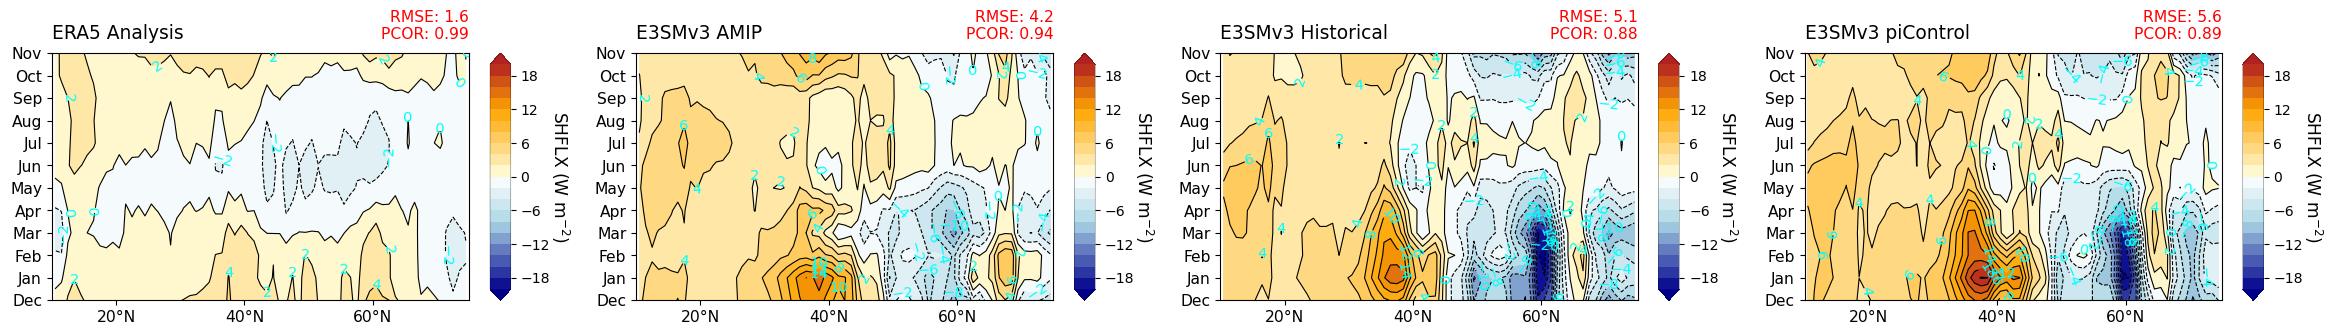

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_SHFLX_Atlantic_model_vs_obs_2001-2018.pdf
[skip] RADNET: missing in ['CERES_EBAF.observation', 'ERA5.analysis', 'v3.LR.amip_ensmn', 'v3.LR.historical_ensmn', 'v3.LR.piControl']
mod_min_max_0_316.2
obs_min_max_0_312.7
mod_min_max_0_319.9
obs_min_max_0_312.7
mod_min_max_0_312.4
obs_min_max_0_312.7
mod_min_max_0_318.3
obs_min_max_0_312.7


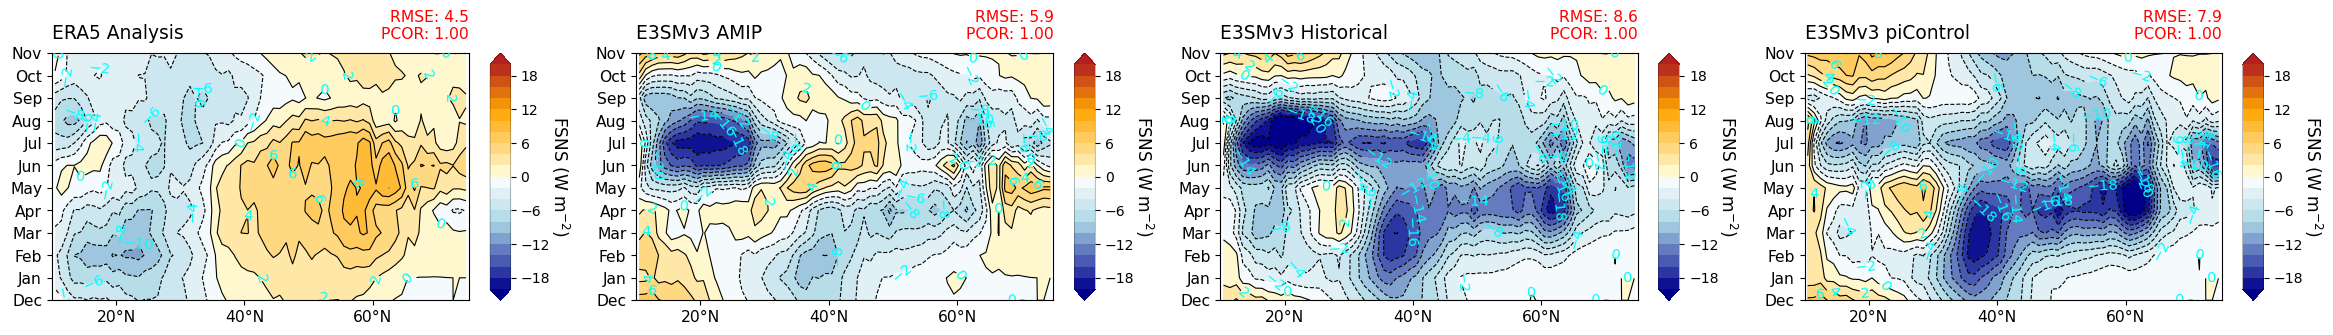

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSNS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-7.1e-07_381.9
obs_min_max_0_389.4
mod_min_max_0_349.5
obs_min_max_0_389.4
mod_min_max_0_350.6
obs_min_max_0_389.4
mod_min_max_0_356.1
obs_min_max_0_389.4


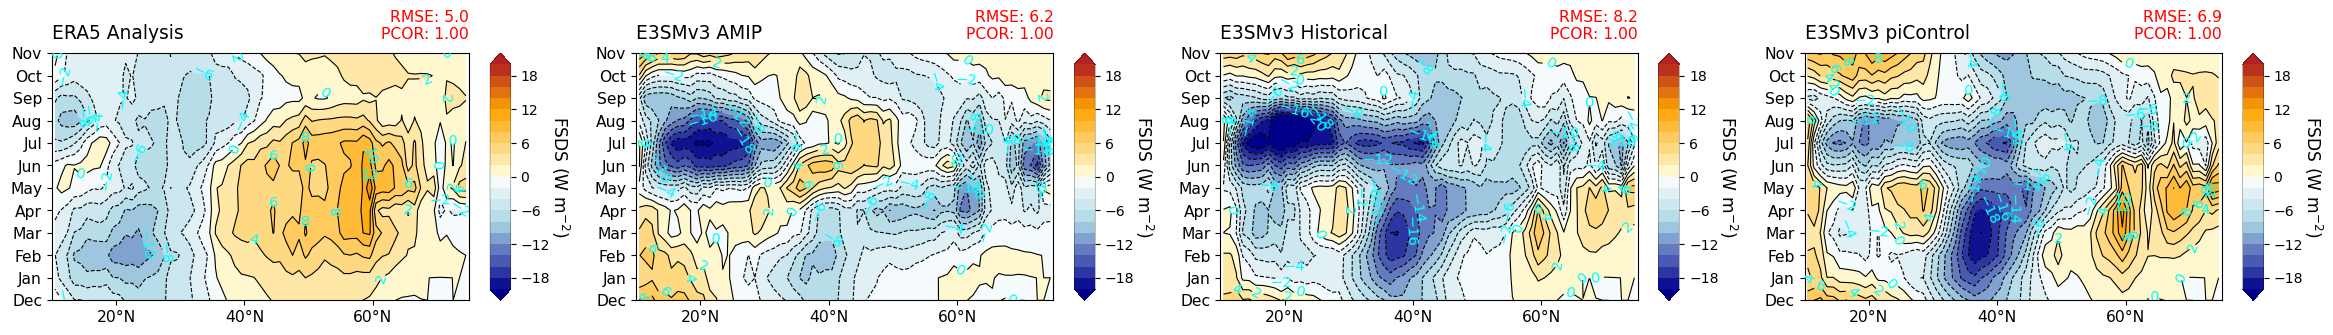

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSDS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-0.001578_320.8
obs_min_max_0_310
mod_min_max_0_258.2
obs_min_max_0_310
mod_min_max_0_257.7
obs_min_max_0_310
mod_min_max_0_266.3
obs_min_max_0_310


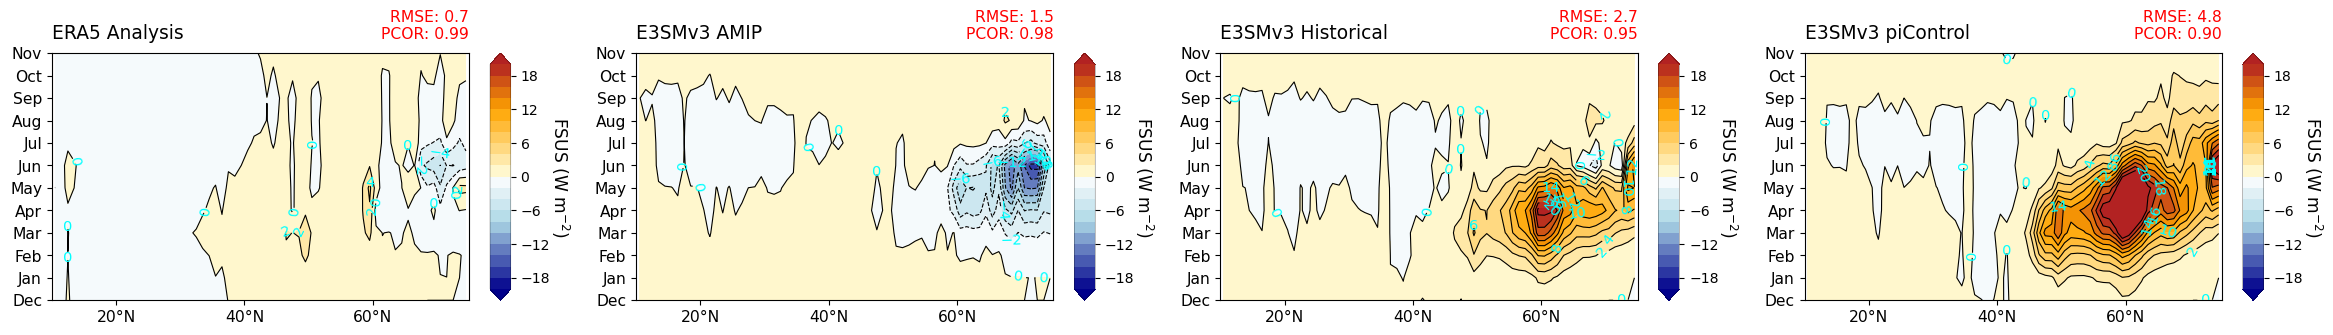

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSUS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-4.312e-14_338
obs_min_max_-0.001333_338.1
mod_min_max_0_337.5
obs_min_max_-0.001333_338.1
mod_min_max_0_336.8
obs_min_max_-0.001333_338.1
mod_min_max_0_340.7
obs_min_max_-0.001333_338.1


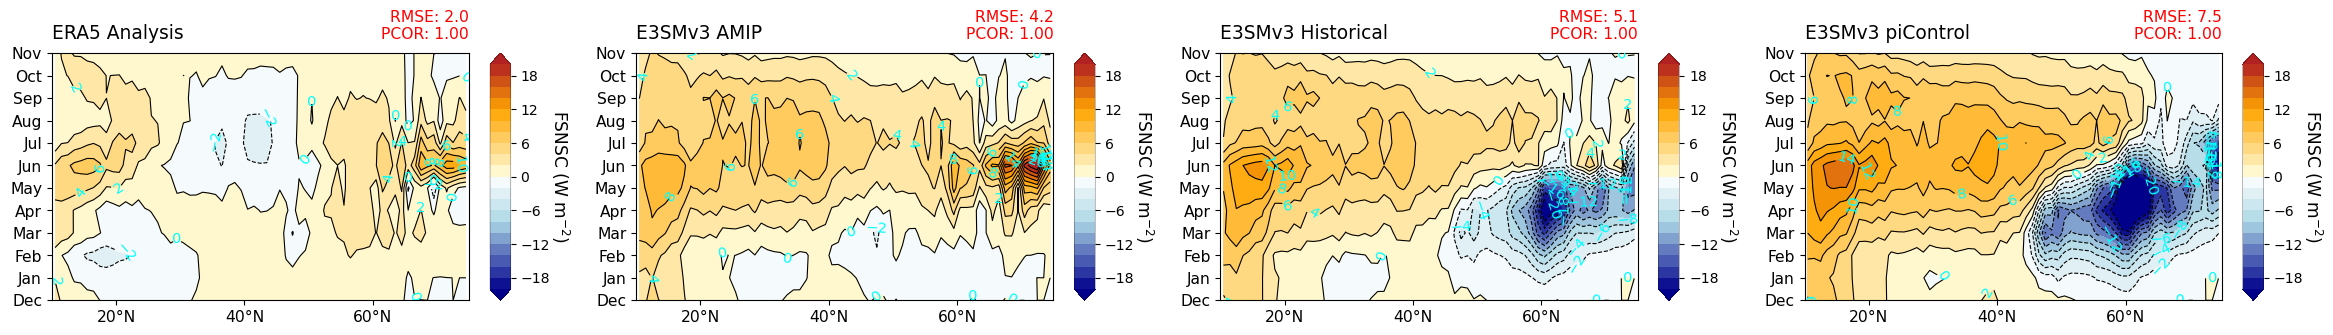

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSNSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_0_404.5
obs_min_max_-0.001522_416.2
mod_min_max_0_403.4
obs_min_max_-0.001522_416.2
mod_min_max_0_403.1
obs_min_max_-0.001522_416.2
mod_min_max_0_406.9
obs_min_max_-0.001522_416.2


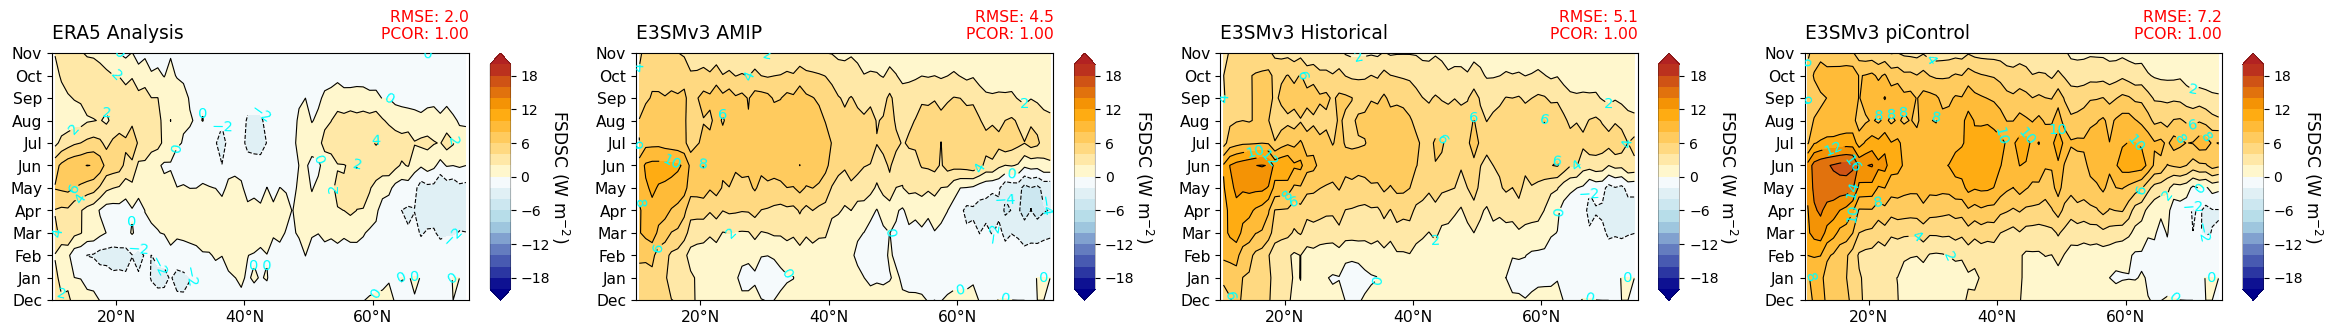

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSDSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-5.344_351.5
obs_min_max_-0.000211_328.8
mod_min_max_0_294.6
obs_min_max_-0.000211_328.8
mod_min_max_0_293.3
obs_min_max_-0.000211_328.8
mod_min_max_0_301.1
obs_min_max_-0.000211_328.8


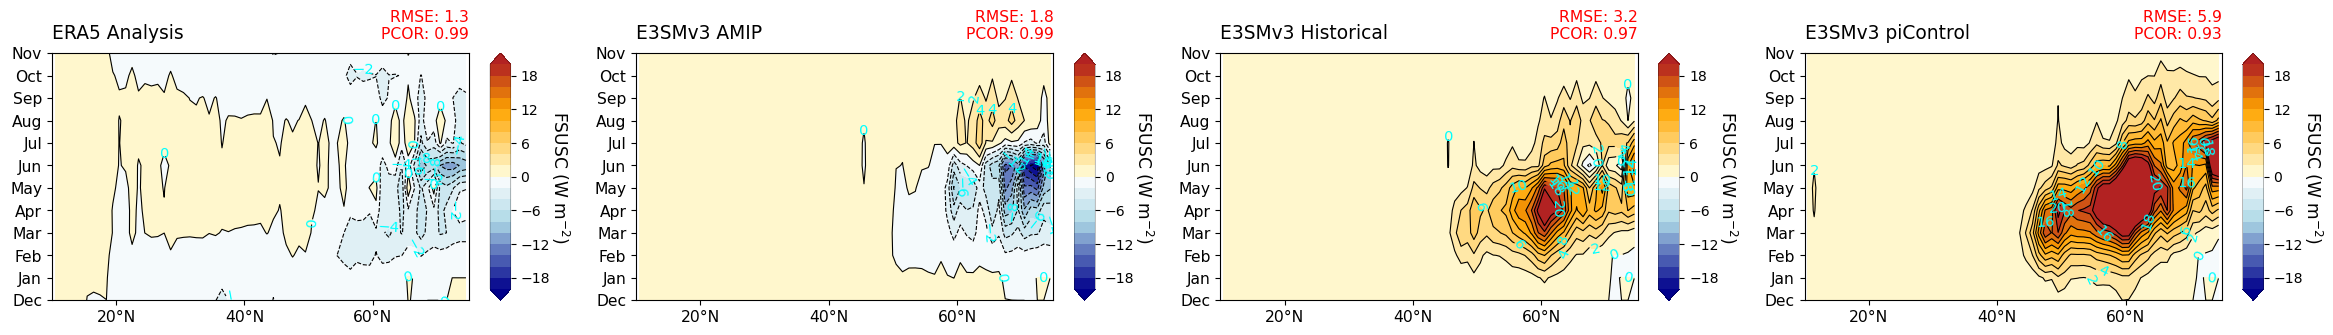

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FSUSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_10.47_168.7
obs_min_max_-7.183_147.8
mod_min_max_4.005_142.1
obs_min_max_-7.183_147.8
mod_min_max_2.674_137.4
obs_min_max_-7.183_147.8
mod_min_max_6.617_141.9
obs_min_max_-7.183_147.8


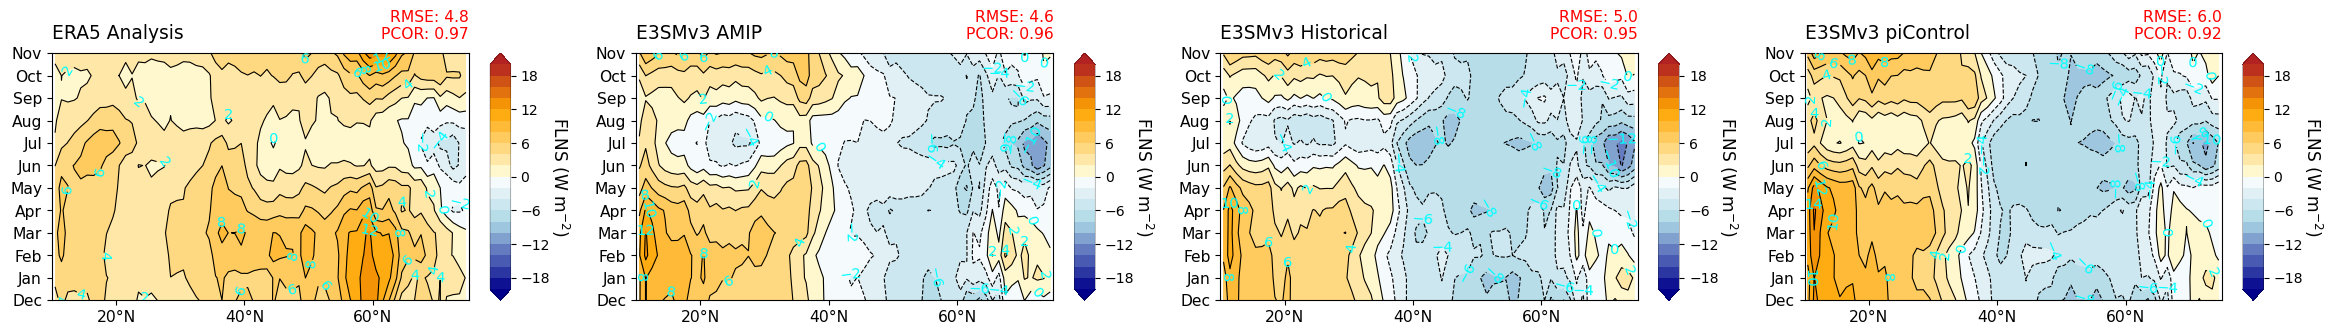

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLNS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_127.2_433.3
obs_min_max_148.8_445.4
mod_min_max_120.7_428.3
obs_min_max_148.8_445.4
mod_min_max_119.6_435.1
obs_min_max_148.8_445.4
mod_min_max_112.6_425.9
obs_min_max_148.8_445.4


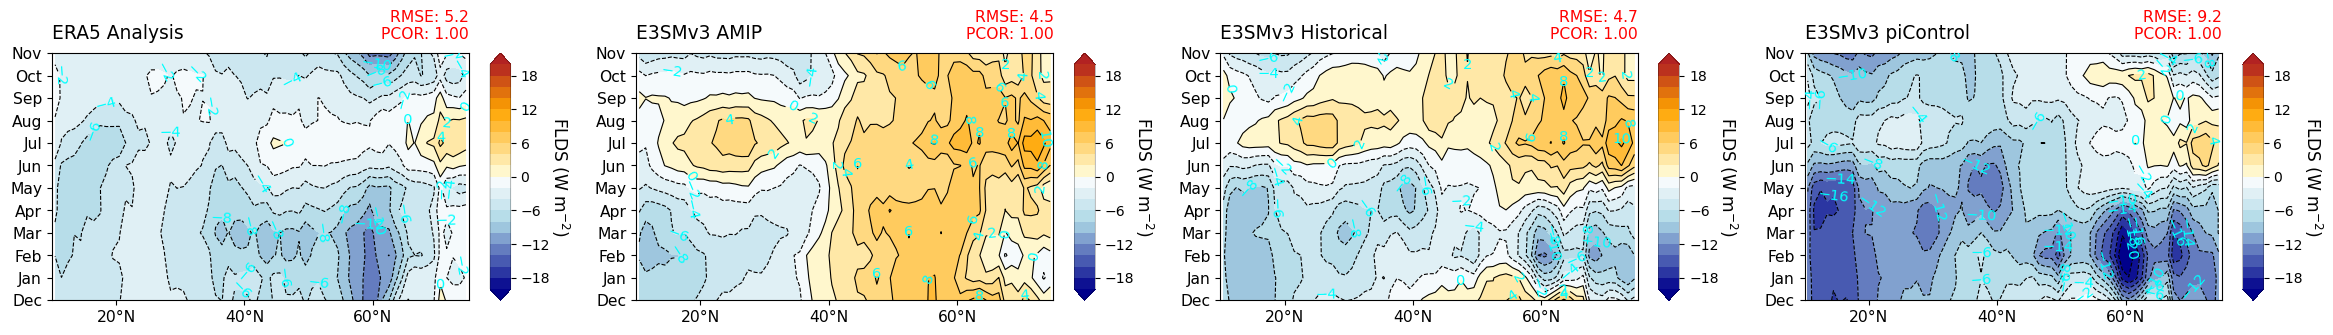

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLDS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_161.7_559.8
obs_min_max_154.3_561.7
mod_min_max_154_548.8
obs_min_max_154.3_561.7
mod_min_max_152.6_544.6
obs_min_max_154.3_561.7
mod_min_max_145.5_532.4
obs_min_max_154.3_561.7


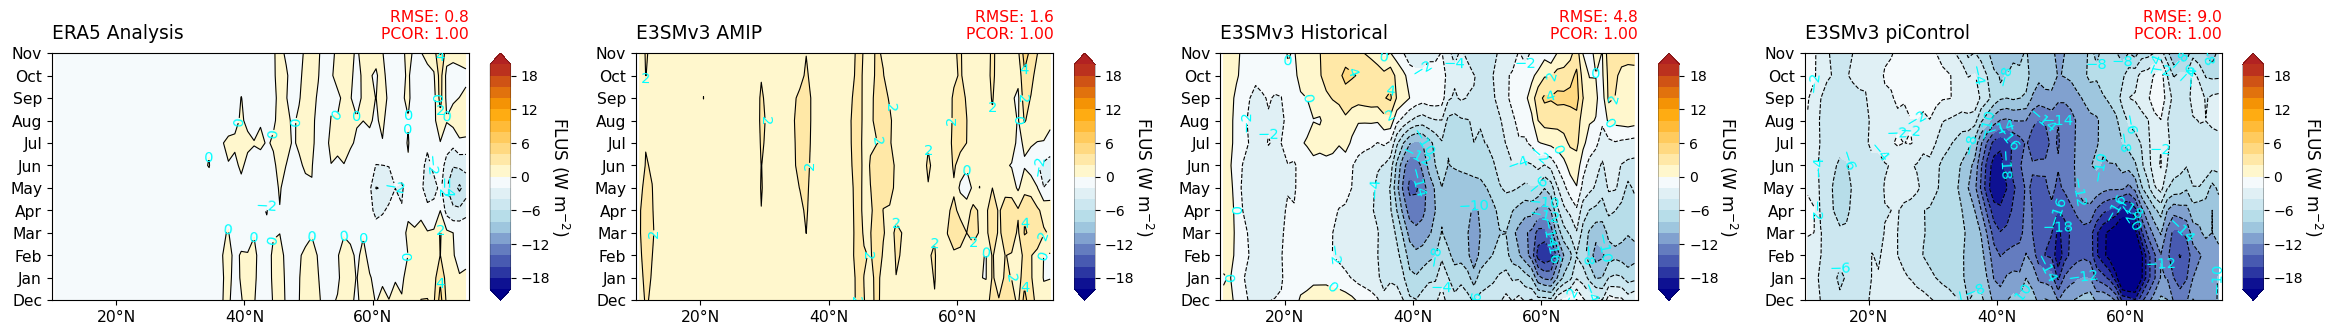

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLUS_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_36.52_169.5
obs_min_max_35.8_188
mod_min_max_41.61_148.1
obs_min_max_35.8_188
mod_min_max_39.84_143
obs_min_max_35.8_188
mod_min_max_38.85_146.2
obs_min_max_35.8_188


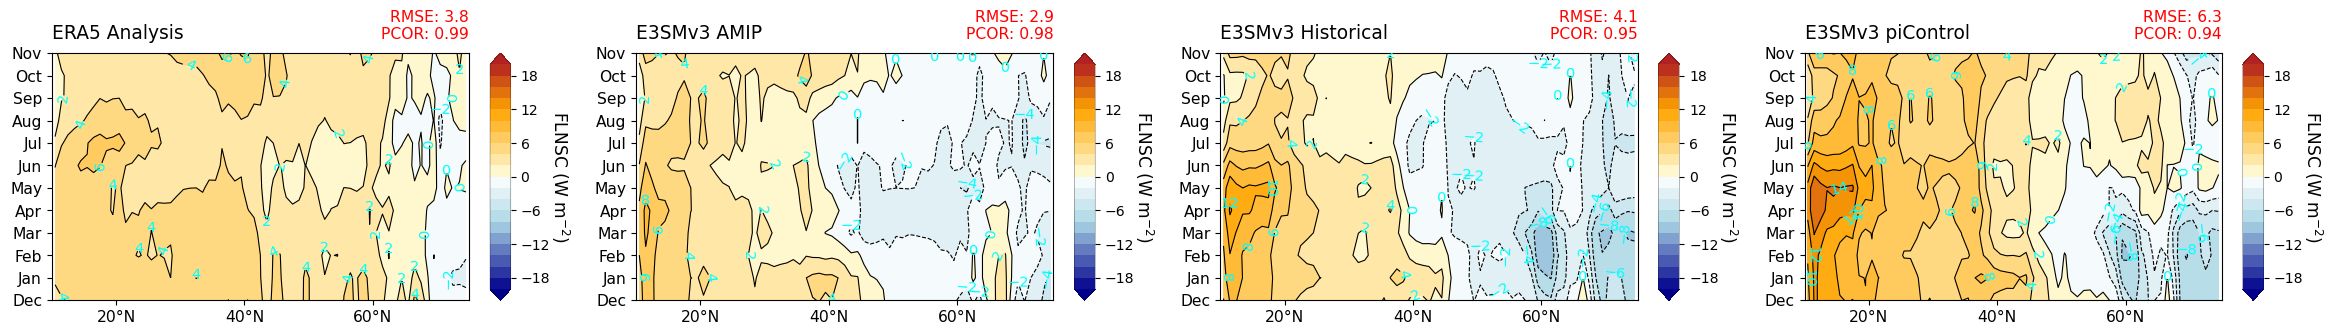

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLNSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_104.8_430.5
obs_min_max_103.3_430.4
mod_min_max_109.7_422.1
obs_min_max_103.3_430.4
mod_min_max_109_430.2
obs_min_max_103.3_430.4
mod_min_max_102.4_420.3
obs_min_max_103.3_430.4


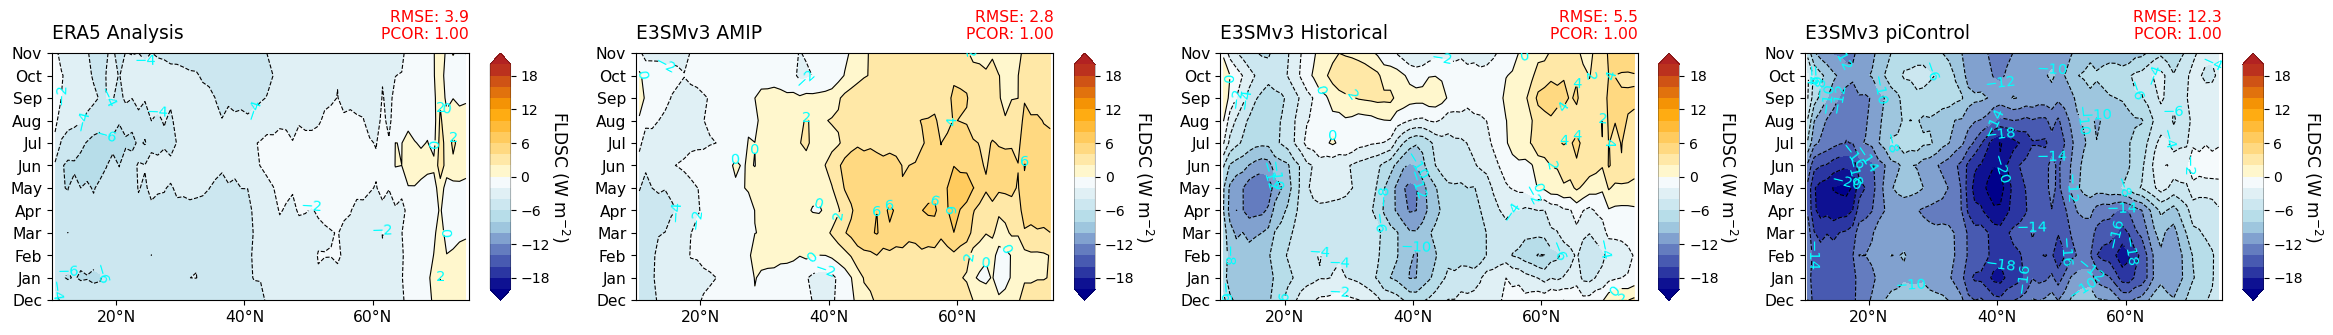

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLDSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_161.7_559.8
obs_min_max_162.2_562.3
mod_min_max_154_548.8
obs_min_max_162.2_562.3
mod_min_max_152.6_544.6
obs_min_max_162.2_562.3
mod_min_max_145.5_532.4
obs_min_max_162.2_562.3


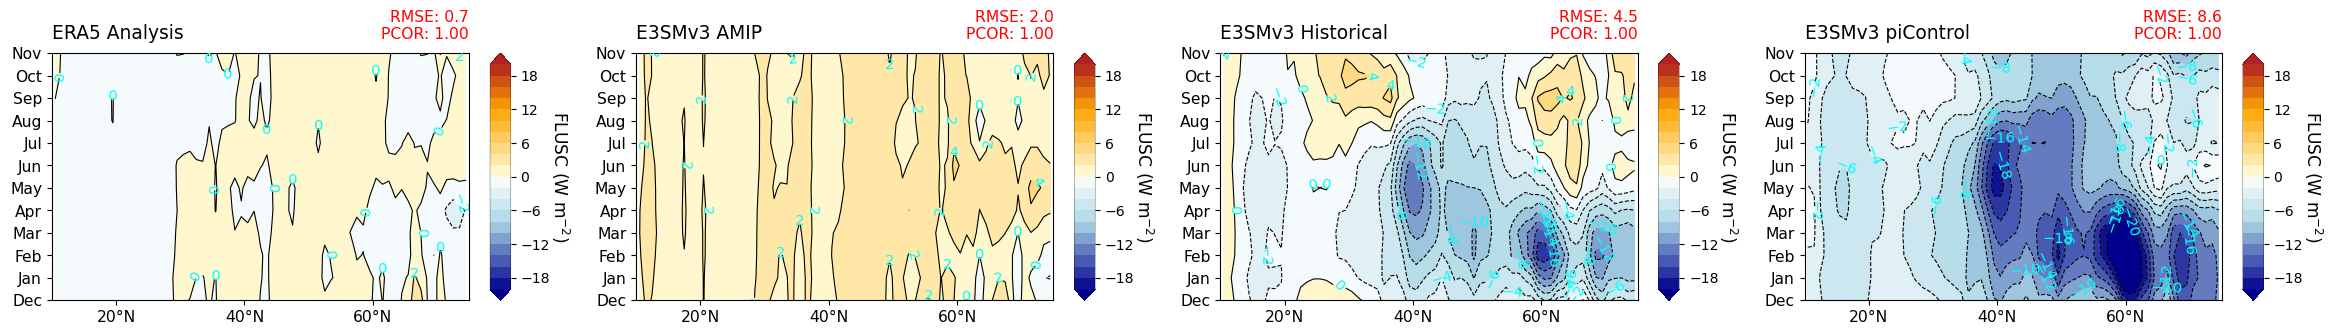

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_FLUSC_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-183.5_58.72
obs_min_max_-162_92.09
mod_min_max_-171.3_3.223e-05
obs_min_max_-162_92.09
mod_min_max_-173.2_2.75e-05
obs_min_max_-162_92.09
mod_min_max_-177.8_5.031e-06
obs_min_max_-162_92.09


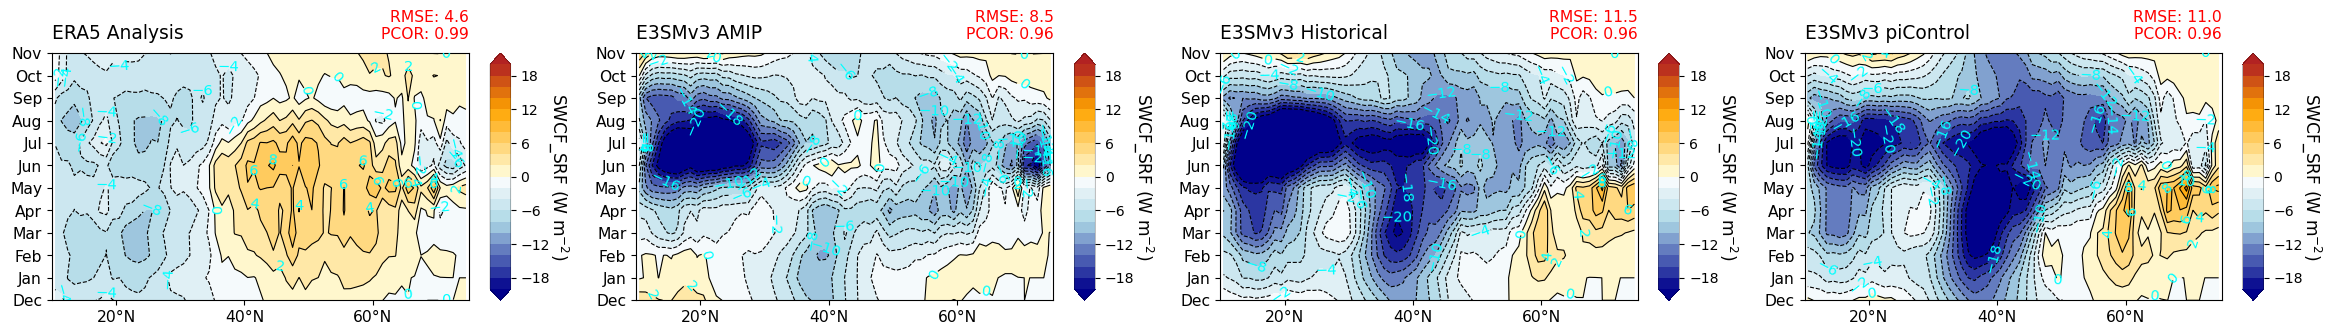

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_SWCF_SRF_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-10.22_76.57
obs_min_max_-7.445_120.1
mod_min_max_0.9168_70.87
obs_min_max_-7.445_120.1
mod_min_max_0.9414_70.99
obs_min_max_-7.445_120.1
mod_min_max_0.8687_73.26
obs_min_max_-7.445_120.1


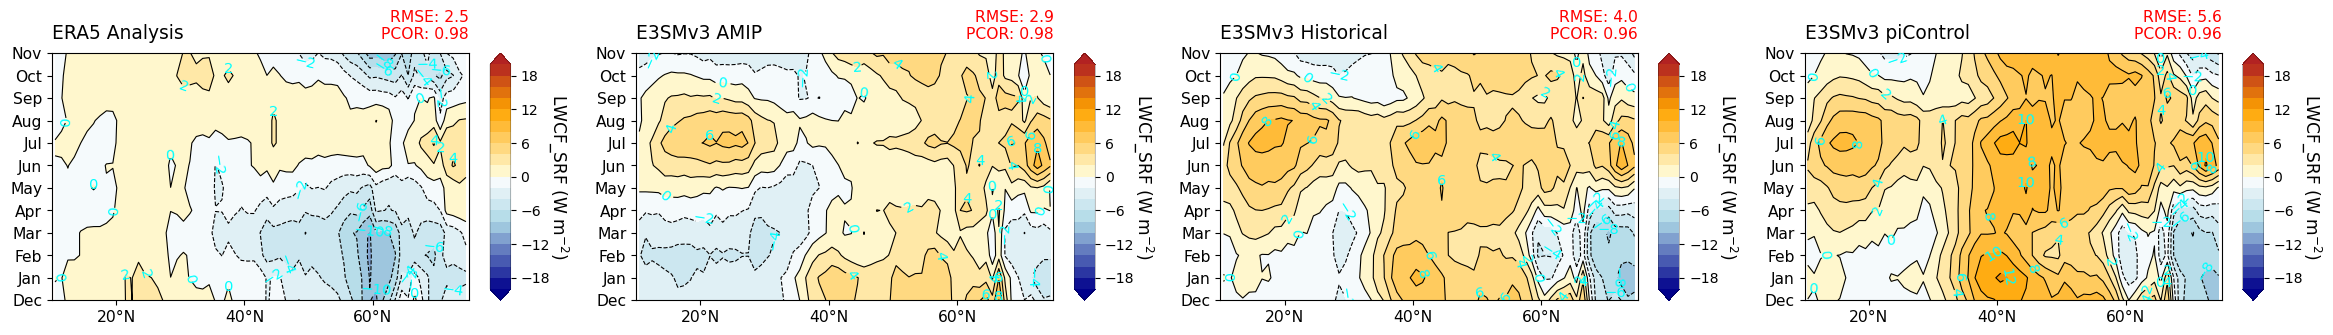

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_LWCF_SRF_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-inf_inf
obs_min_max_0.02304_0.9985


/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xskillscore/core/np_deterministic.py:314: RuntimeWarning: invalid value encountered in scalar divide
  r = r_num / r_den


mod_min_max_0.04327_0.9484
obs_min_max_0.02304_0.9985
mod_min_max_0.04334_0.9482
obs_min_max_0.02304_0.9985
mod_min_max_0.04333_0.9506
obs_min_max_0.02304_0.9985


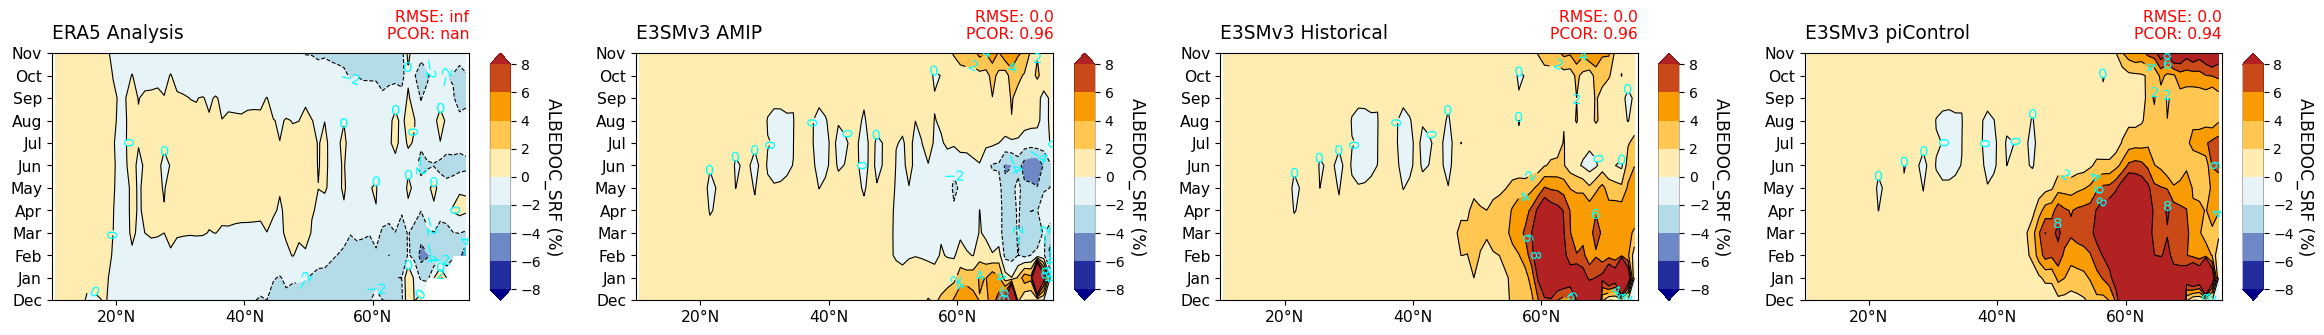

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_ALBEDOC_SRF_Atlantic_model_vs_obs_2001-2018.pdf
mod_min_max_-0.04909_2223
obs_min_max_0.02476_1
mod_min_max_0.04389_0.9487
obs_min_max_0.02476_1
mod_min_max_0.04359_0.9483
obs_min_max_0.02476_1
mod_min_max_0.04359_0.9509
obs_min_max_0.02476_1


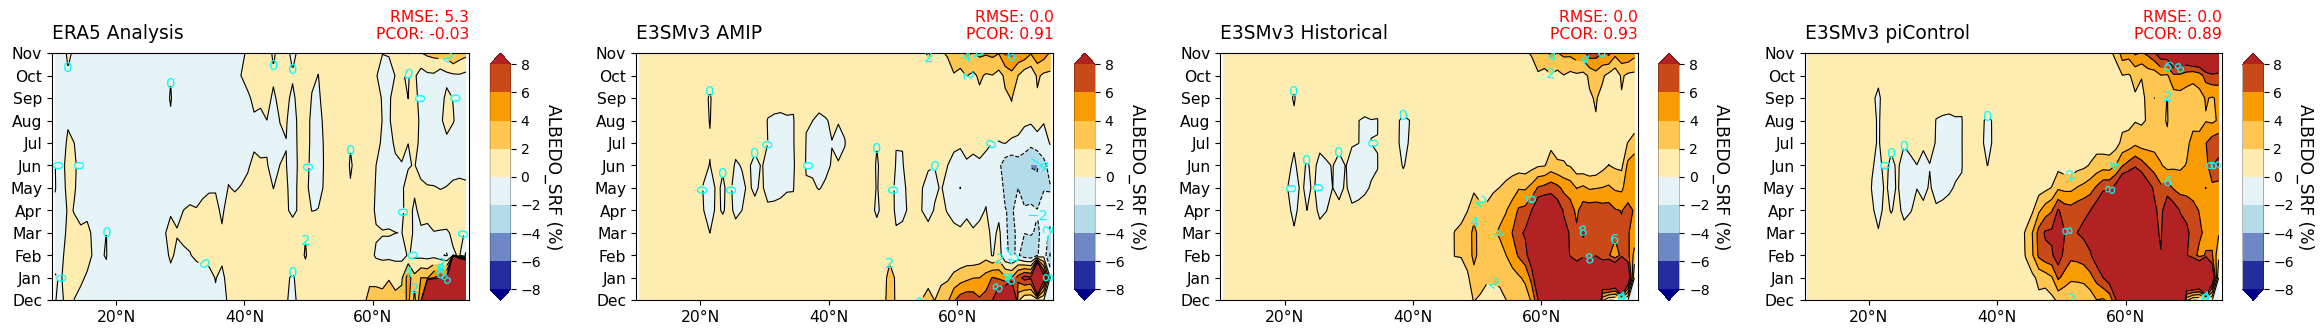

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_bias_ALBEDO_SRF_Atlantic_model_vs_obs_2001-2018.pdf


In [4]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis"
    data_path = f"{top_path}/data/climo"
    out_path  = f"{top_path}/diag_data"
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Atlantic"
    dtype      = "climo"
    plot_type  = "model_vs_obs"

    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

    refexp         = "HadISST.analysis"       # must exist in RUN_CATALOG
    sfc_mask_ref   = "HadISST.analysis"     # must exist in RUN_CATALOG
    sfc_mask_kind  = "ocean"
    sfc_mask_var   = "TS"
    
    variables  = list(VARIABLE_CATALOG.keys())  # e.g., ['TS','ALBEDOC_SRF','ALBEDO_SRF']

    # --- echo metadata safely ---
    run_info = RUN_CATALOG[refexp]
    try:
        ref_name = run_info.name
        ref_period = run_info.period
    except AttributeError:
        ref_name = run_info["name"]
        ref_period = run_info["period"]

    reg_info = REGION_CATALOG[regnam]
    try:
        (lat_min, lat_max) = reg_info.lat_range
        (lon_min, lon_max) = reg_info.lon_range
    except AttributeError:
        (lat_min, lat_max), (lon_min, lon_max) = reg_info

    print(f"reference data and period: {ref_name}, {ref_period}")
    print(f"processed region: {regnam}, lat=({lat_min},{lat_max}), lon=({lon_min},{lon_max})")

    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)

    # --- read regionalized datasets ---
    reader = ExpDataReader(
        data_dir=data_path,
        regnam=regnam,
        dtype=dtype,
        sfc_mask_ref=sfc_mask_ref,
        sfc_mask_var=sfc_mask_var,
        sfc_mask_kind=sfc_mask_kind,
        verbose=True,
    )
    run_catalog, exp_dict, surface_mask = reader.read()

    print("Loaded runs:")
    pprint.pprint(list(run_catalog.keys()))

    # models to plot (exclude the reference for model-vs-obs bias panels)
    model_list = [k for k in run_catalog if k != refexp]
    for exclude in [
        'MODIS.observation',
        "HadISST.analysis",
        'CERES_EBAF.observation',
        'ERA5.ensmn',
        'MERRA2.analysis',
        #'ERA5.analysis',
        'v3.LR.piControl.hexagonal',
        '20250327.v3.SORRME3r3.piControl.alfred2.chrysalis',
    ]:
        if exclude in model_list:
            model_list.remove(exclude)
    
    # --- figure scaling (no seasons; single row of panels) ---
    ncols = max(len(model_list), 1)
    base_w, base_h = 35.0, 12.0         # tuned for ~5 columns
    fcol = ncols / 5.0
    fgw  = base_w * fcol
    fgh  = base_h                         # single row
    ws, hs = 0.4, 0.2
    fontz = 10

    # helper to sanitize periods used in filenames
    save_period = ref_period.replace("\u2010","-").replace("\u2011","-").replace("\u2012","-") \
                                .replace("\u2013","-").replace("\u2014","-").replace("\u2212","-")
     
    # --- loop over variables ---
    for var_key in variables:
        vinfo = VARIABLE_CATALOG[var_key]
        # handle both dict and object styles
        if isinstance(vinfo, dict):
            v_unit = vinfo.get("unit", "")
            v_min  = vinfo.get("min", None)
            v_max  = vinfo.get("max", None)
            v_nlev = vinfo.get("nlev", 11)
            v_ref  = vinfo.get("ref", None)
            v_fac  = vinfo.get("fac", 1.0)
        else:
            v_unit = getattr(vinfo, "unit", "")
            v_min  = getattr(vinfo, "min", None)
            v_max  = getattr(vinfo, "max", None)
            v_nlev = getattr(vinfo, "nlev", 11)
            v_ref  = getattr(vinfo, "ref", None)
            v_fac  = getattr(vinfo, "fac", None)

        var_dict = {
            "var":  var_key,
            "unit": v_unit,
            "min":  v_min,
            "max":  v_max,
            "nlev": v_nlev,
            "ref":  v_ref,
            'fac':  v_fac,
        }

        # quick availability check across all needed datasets
        missing = [k for k in ([v_ref] + model_list) if var_key not in exp_dict[k].data_vars]
        if missing:
            print(f"[skip] {var_key}: missing in {missing}")
            continue

        plotter = ZonalMeanBiasPlotter(
            run_dict=run_catalog,
            df=exp_dict,
            lmsk=surface_mask,
            var_dict=var_dict,
            months=months,
            regnam=regnam,
            model_list=model_list,
            plot_type=plot_type,
            fgw=fgw, fgh=fgh,
            ws=ws, hs=hs,
            region_catalog=REGION_CATALOG,
        )

        # expected filename produced by the class (so we can move/rename)
        # class builds: f"fig_zonalmean_{plot_type}_{ref_str}_{self.var}_{self.regnam}_{period}.pdf"
        expected_outname = f"fig_zonalmean_{plot_type}_{refexp}_{var_key}_{regnam}_{save_period}.pdf"
        desired_savepath = os.path.join(
            fig_dir,
            f"fig_zonal_bias_{var_key}_{regnam}_{plot_type}_{save_period}.pdf"
        )

        try:
            # class does not accept savepath/fontz; it saves into CWD
            produced = plotter.plot(show=True)  # returns outname
            # produced should equal expected_outname; move to desired path
            src = produced if isinstance(produced, str) else expected_outname
            if os.path.exists(src):
                shutil.move(src, desired_savepath)
                print(f"[ok] saved: {desired_savepath}")
            else:
                # fallback: try to locate any file that matches the class pattern
                candidates = [expected_outname]
                for cand in candidates:
                    if os.path.exists(cand):
                        shutil.move(cand, desired_savepath)
                        print(f"[ok] saved: {desired_savepath}")
                        break
                else:
                    print(f"[warn] expected output '{expected_outname}' not found; left in default location.")
        except Exception as e:
            print(f"[fail] {var_key}: {e}")
